# Calibrate A Day

This notebook performs calibration of a day's averaged spectrum. This is the same as `edges2k.c`.

In [1]:
datadir: str = "."
dayavgfile: str = "2016-250.averaged.gsh5"
calfile: str = "specal.txt"
ants11file: str = "2015_ants11_modelled.h5"
beamfactorfile: str = "beam_factor.hickle"

alan_output_dir = "/data4/smurray/edges/alans-pipeline/scripts/H2CaseFieldData/"

fmin: float = 50   # Minimum freq to keep in the data       
fmax: float = 100  # Maximum freq to keep in the data

cal_freq_min: float = 51  # Minimum freq to *use* (i.e. with weight>0)
cal_freq_max: float = 99

do_beam_correction: bool = True
# beam_model can be:
# - 'inject': inject the full beam correction computed by the legacy code (for testing)
# - 'legacy-lsts': use the LSTs computed by the legacy code, but do all other computation with edges-analysis
# - 'legacy-lst-grid': compute an LST grid inspired by the legacy code (it won't exactly match)
# - 'all-lsts': use all observed LSTs from the day (including flagged integrations)
# - 'all-unflagged-lsts': use all unflagged LSTs from the day

beam_mode: str = 'inject' 
lst_wrap_hours: float = 20 # only used for 'legacy-lst-grid'

## Imports and Data Load

In [ ]:
from pathlib import Path
import numpy as np
from astropy import units as un
import hickle

from pygsdata import GSData
from pygsdata.select import select_freqs

from edges.cal import Calibrator, ReflectionCoefficient, S11ModelParams
from edges.alanmode import read_specal
from edges import modeling as mdl
from edges.analysis.calibrate import apply_beam_correction, apply_loss_correction, apply_noise_wave_calibration
from edges.analysis.loss import low2_balun_connector_loss
from edges.averaging.freqbin import gauss_smooth
from edges.averaging import NsamplesStrategy
from edges.analysis.datamodel import add_model
from edges.filters import filters
from edges.sim import BeamFactor

from edges_pipeline_utils import utils

In [3]:
utils.print_versions()


Versions: 
            read_acq: 1.1.1
            pygsdata: 0.2.2.dev45+gd90fcd3
      edges-analysis: 7.0.1.dev39+g46fc9f9


In [ ]:
if beam_mode not in ['inject', 'legacy-lsts', 'legacy-lst-grid', 'all-lsts', 'all-unflagged-lsts']:
    raise ValueError("beam_mode must be one of 'inject', 'legacy-lsts', 'legacy-lst-grid', 'all-lsts', 'all-unflagged-lsts'")

In [4]:
dayavgfile = Path(dayavgfile)

In [5]:
year, day = dayavgfile.stem.split(".")[0].split("-")
year = int(year)
day = int(day)
datadir = Path(datadir)
alan_output_dir = Path(alan_output_dir) / str(utils.yday_to_alanday(year, day))

In [6]:
pre_cal_data = GSData.from_file(dayavgfile)

In [7]:
if calfile.endswith(".txt"):
    calobs = read_specal(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

### Noise-Wave Calibration

In [8]:
nw_data = select_freqs(pre_cal_data, freq_range=(fmin*un.MHz, fmax*un.MHz))

In [9]:
nw_data = filters.flag_frequency_ranges(nw_data, freq_ranges=((cal_freq_min, cal_freq_max),), invert=True)

In [10]:
alan_pre_cal = np.genfromtxt(alan_output_dir/"spectra_before_noise_waves.txt")

In [11]:
ant_s11 = ReflectionCoefficient.from_file(ants11file)

In [ ]:
model_params = S11ModelParams(
    model=mdl.Polynomial(n_terms=10, transform=mdl.LogTransform(scale=1.0)),       
    complex_model_type=mdl.ComplexRealImagModel,
    set_transform_range=True,
    fit_method='lstsq',
    find_model_delay=True,
)

In [ ]:
ant_s11 = ant_s11.smoothed(params=model_params, freqs = nw_data.freqs)

In [12]:
nw_data = apply_noise_wave_calibration(
    nw_data,
    calibrator = calobs,
    antenna_s11=ant_s11,
    tload=300.0,
    tns=1000,
)

In [13]:
alan_spec_after_nw = np.genfromtxt(alan_output_dir/"spectra_after_noise_waves.txt", names=True)

In [14]:
alan_ants11 = np.genfromtxt(alan_output_dir/"modeled_antenna_s11.txt")

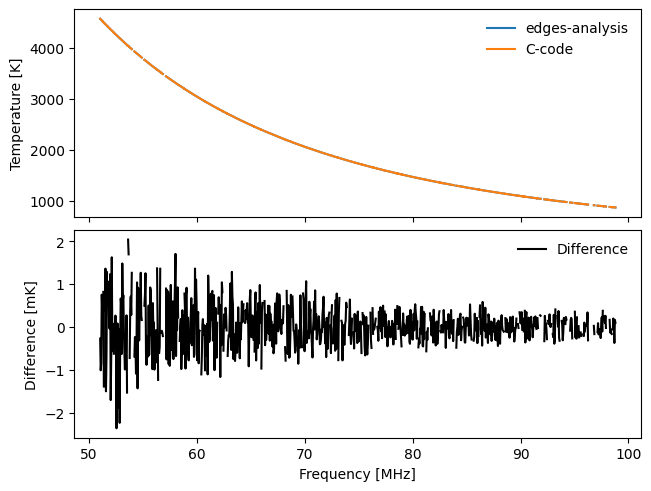

In [15]:
utils.plot_single_spectrum(nw_data, alan_spec_after_nw['spec'])

### Loss-Correction

In [16]:
# Apply different loss corrections

# los
loss_data = apply_loss_correction(
    nw_data, 
    ambient_temp=296*un.K, 
    loss = low2_balun_connector_loss(ant_s11, use_approx_eps0=True),
)
# no antenna correction
# no ground loss

In [17]:
alan_spec_after_loss = np.genfromtxt(alan_output_dir / "spectra_after_loss.txt", names=True)

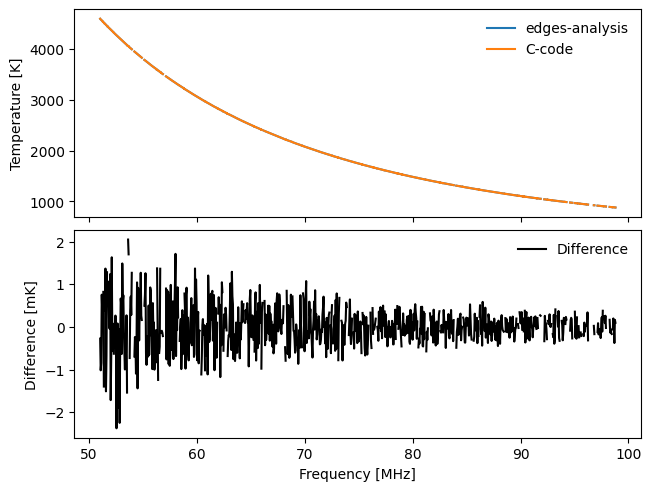

In [18]:
utils.plot_single_spectrum(loss_data, alan_spec_after_loss['spec'])

### Beam Correction

In [ ]:
if do_beam_correction:
    if beam_mode == 'inject':
        beamfac = np.genfromtxt(alan_output_dir/'beamcorr.txt')
        beam_data = loss_data.update(data=loss_data.data * beamfac[:, 3])
    else:
        beam = BeamFactor.from_file(beamfactorfile)
        if beam_mode == 'legacy-lsts':
            lsts = []
            beamfacs = sorted(alan_output_dir.glob("beamfac*.txt"), key=lambda pth: int(pth.stem[7:]))
    
            for bf in beamfacs:
                with open(bf, 'r') as fl:
                    lsts.append(float(fl.readlines()[1].split("=")[-1].strip()))
            lsts = np.array(lsts)
        else:
            lsts = np.genfromtxt(dayavgfile.parent / dayavgfile.name.replace(".averaged.gsh5", ".lsts.txt"))
            
            if beam_mode=='legacy-lst-grid':
                flgs = np.load(dayavgfile.parent / dayavgfile.name.replace(".averaged.gsh5", ".integration-flags.npz"))
                
                _f = np.zeros(len(lsts), dtype=bool)
                for k, v in flgs.items():
                    _f |= v.squeeze()

                lsts[lsts>lst_wrap_hours] -= 24.0

                
                flsts = lsts[~_f]
                # The C-code uses swpos=2 to calculate the mean time, not swpos=0,
                # so we add 26 seconds here to get a reasonably accurate mean time.
                mean_lst = np.mean(flsts) + 26.0/60/60
                lst_range = flsts.max() - flsts.min()

                nlst = int(lst_range // 0.5 + 1)
                dlst = lst_range / nlst

                lst_edges = np.linspace(mean_lst - lst_range/2, mean_lst + lst_range/2, nlst + 1)
                lsts = (lst_edges[1:] + lst_edges[:-1])/2
            elif beam_mode=='all-unflagged-lsts':
                flgs = np.load(dayavgfile.parent / dayavgfile.name.replace(".averaged.gsh5", ".integration-flags.npz"))
                _f = np.zeros(len(lsts), dtype=bool)
                for k, v in flgs.items():
                    _f |= v.squeeze()

                lsts = lsts[_f]
                
        beam_data = apply_beam_correction(
            loss_data, 
            beam=beam,
            freq_model = mdl.Fourier(
                n_terms=31, 
                transform=mdl.ShiftTransform(shift=75.0), 
                period=1.2*beam.nfreq * (beam.frequencies[1] - beam.frequencies[0])
            ),
            resample_beam_lsts = True,
            integrate_before_ratio = True,
            lsts=lsts,
            cut_to_data_lsts=False,
        )
else:
    beam_data = loss_data

In [20]:
# Get Alan's file after beam correction. NOTE: if beam correction is turned off in the script running the C-code, then this
# will NOT have beam correction actually applied, and will be the same as the previous plot.
alan_after_beam = np.genfromtxt(alan_output_dir/"spectra_after_beam.txt", names=True)

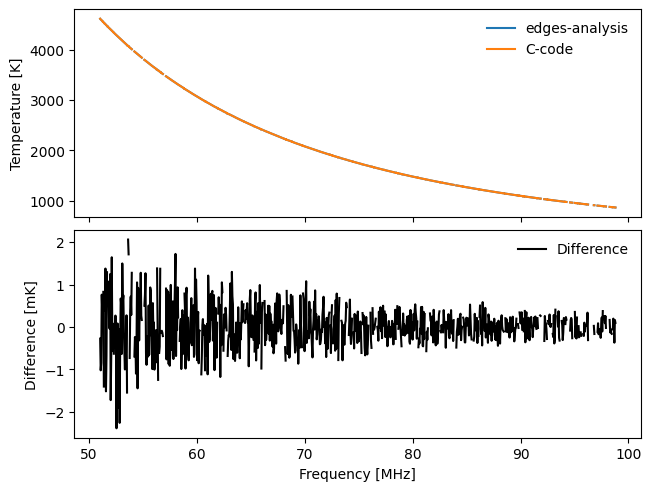

In [21]:
utils.plot_single_spectrum(beam_data, alan_after_beam['spec'])

### Smooth Over Frequencies Again

In [22]:
data = add_model(beam_data, model=mdl.PhysicalLin(n_terms=3, spectral_index=-2.5, f_center=75.0, with_cmb=False), nsamples_strategy=NsamplesStrategy.FLAGGED_NSAMPLES_UNIFORM)

In [23]:
alan_mdl = np.genfromtxt(alan_output_dir /"second_smooth_input.txt", names=True)

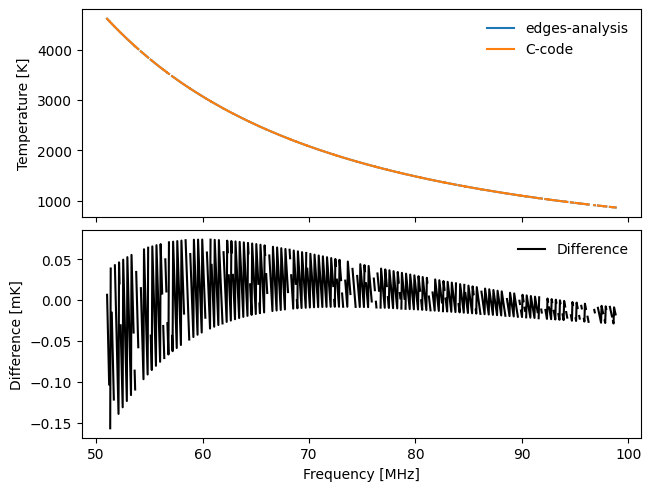

In [24]:
utils.plot_single_spectrum(data, alan_mdl['model'], attribute='model')

In [25]:
data = gauss_smooth(data, size=8, nsmooth=2, decimate_at=0, maintain_flags=9, use_residuals=True, use_nsamples=False)

In [26]:
alan_specavg = np.genfromtxt(alan_output_dir / "specavg_cal.txt", usecols=(1,3,9))

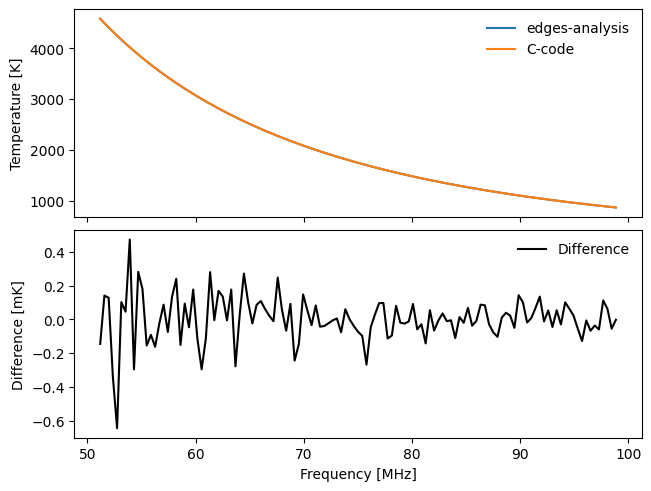

In [27]:
utils.plot_single_spectrum(data, alan_specavg[:, 1])

In [28]:
data.write_gsh5(dayavgfile.parent / dayavgfile.name.replace(".averaged.", ".finalspec."));